# ITS Digital Twin: Perception Pipeline
This notebook downloads the AIC22 CityFlow dataset, extracts vehicle trajectories, projects them to 3D world coordinates, and exports the data for the Three.js frontend.

In [1]:
!pip install -q ultralytics supervision opencv-python-headless kaggle scipy numpyx

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.2/88.2 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 376.6/376.6 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 671.9/671.9 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 34.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.3/144.3 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.3/65.3 kB 3.3 MB/s eta 0:00:00


In [ ]:
import os
from google.colab import userdata
try:
    os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
    os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')
    print('Kaggle credentials loaded from Colab Secrets.')
except Exception:
    import getpass
    print('Please enter your Kaggle credentials.')
    os.environ['KAGGLE_USERNAME'] = getpass.getpass('KAGGLE_USERNAME: ')
    os.environ['KAGGLE_KEY'] = getpass.getpass('KAGGLE_KEY: ')

!kaggle datasets download -d shanthinisampath1/cityflow-multi-camera-tracking-dataset --unzip -p ./cityflow

Kaggle credentials loaded from Colab Secrets.
Dataset URL: https://www.kaggle.com/datasets/shanthinisampath1/cityflow-multi-camera-tracking-dataset
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)
100% 15.8G/15.8G [13:08<00:00, 21.5MB/s]



Ground-Plane Homography Matrix (H):
[[ 2.04110747e-01 -3.46549666e-02 -1.81664565e+02]
 [ 5.49339536e-03  3.99991582e-01 -2.64682968e+02]
 [ 9.21546275e-05  2.13319340e-03  1.00000000e+00]]
Calibration check — verify the red box outlines real flat ground:


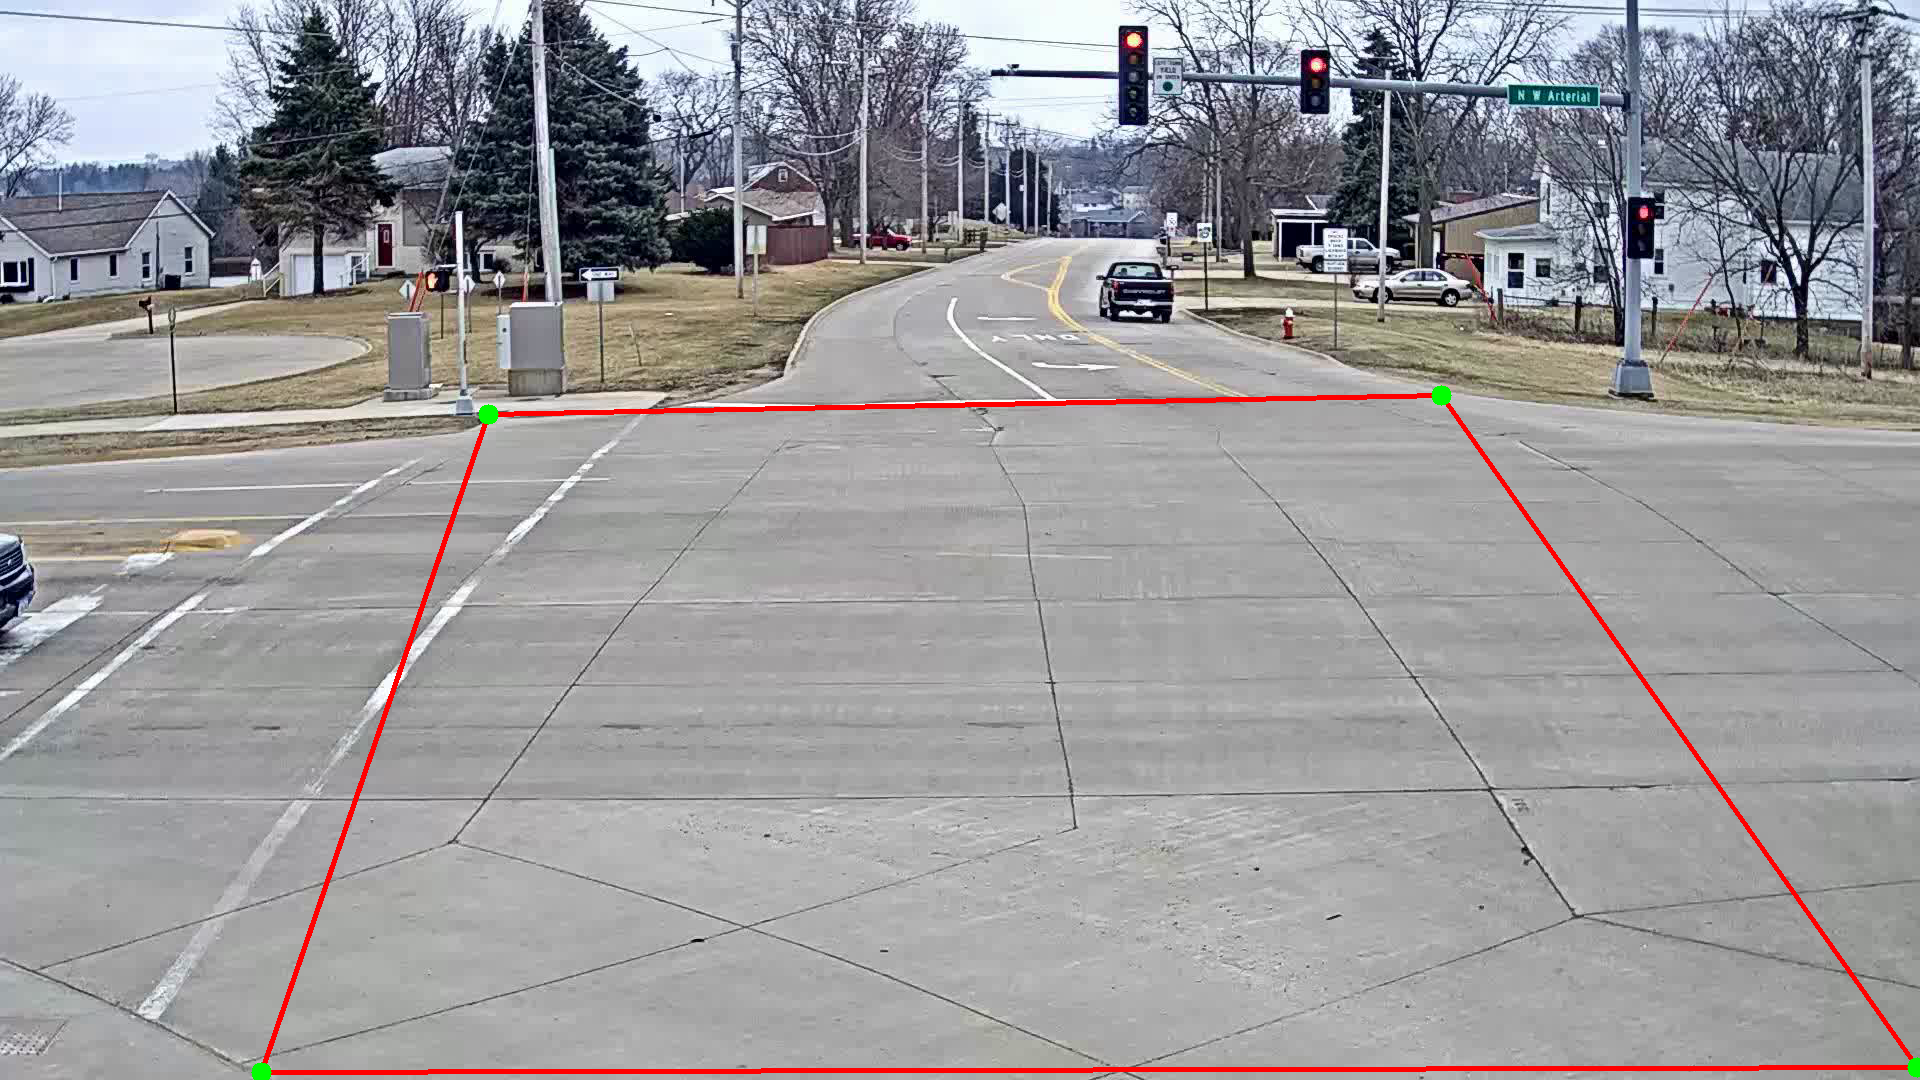

In [3]:
import numpy as np
import cv2

# --- 1. Manual 4-Point Ground Plane Homography ---
# These 4 pixel coordinates mark the corners of a real-world flat rectangle
# (the concrete apron directly in front of the camera) in the FIRST frame of
# feed.mp4. If you swap in a different CityFlow camera/video, you MUST
# re-pick these 4 points to match the new frame — use the visualization
# below to verify them before trusting anything downstream.
SRC_POINTS = np.array([
    [488, 414],   # Top-Left
    [1441, 395],  # Top-Right
    [1917, 1067], # Bottom-Right
    [261, 1072]   # Bottom-Left
], dtype=np.float32)

# Map them to a metric ground-plane rectangle (X: -50m to +50m, Z: -50m to +50m)
DST_POINTS = np.float32([[-50, -50], [50, -50], [50, 50], [-50, 50]])

# Compute Homography: maps pixel (u, v) -> ground-plane world (X, Z) in meters
H, _ = cv2.findHomography(SRC_POINTS, DST_POINTS)

print('Ground-Plane Homography Matrix (H):')
print(H)

def project_to_ground(u, v, H):
    px = np.array([[[u, v]]], dtype=np.float32)
    world_pt = cv2.perspectiveTransform(px, H)[0][0]
    return float(world_pt[0]), float(world_pt[1])

# --- Calibration sanity-check visualization ---
# Grabs the first frame of the source video and draws the 4 calibration
# points + connecting quadrilateral on it. The red quadrilateral must trace
# the edges of the flat road/pavement region in the video, and each green
# dot must sit exactly on a real ground-level corner (curb line, lane-paint
# corner, crosswalk corner, etc). If it does not line up, edit SRC_POINTS
# above and re-run this cell before continuing to Cell 4.
_cap_check = cv2.VideoCapture('./cityflow/train/S01/c001/vdo.avi')
_ret_check, _frame_check = _cap_check.read()
_cap_check.release()
if _ret_check:
    _vis = _frame_check.copy()
    _pts_int = SRC_POINTS.astype(np.int32)
    cv2.polylines(_vis, [_pts_int], True, (0, 0, 255), 4)
    for _p in _pts_int:
        cv2.circle(_vis, tuple(_p), 10, (0, 255, 0), -1)
    cv2.imwrite('calibration_check.png', _vis)
    from IPython.display import Image as IPyImage, display
    print("Calibration check — verify the red box outlines real flat ground:")
    display(IPyImage('calibration_check.png'))
else:
    print("WARNING: could not read first frame for calibration check.")


In [4]:
!pip install -q transformers

import cv2
import json
import numpy as np
from ultralytics import YOLO
from scipy.signal import savgol_filter, medfilt

# =========================================================================
# TUNABLE CONSTANTS — grouped here so they're easy to find and adjust later
# =========================================================================
MIN_TRACK_LENGTH = 5        # was 15. Minimum frames a track must span to be kept.
DETECTION_IMGSZ = 1280      # was default 640. Higher = smaller/farther vehicles get detected.
DETECTION_CONF = 0.15       # was default 0.25. Lower = more recall on distant/small vehicles.
EXT_HALF_SIZE = 120.0       # was 50.0. Half-width in meters of the exported ground/texture area.
PIXELS_PER_METER = 10       # texture density — matches the original 1000px / 100m patch.
SPEED_HARD_CAP_KMH = 120.0
BOUNDARY_MARGIN_PX = 3      # a bbox edge within this many px of the frame border is "clipped"

# --- Custom ByteTrack config with a larger track_buffer so tracks survive
#     brief occlusions (behind poles, other vehicles) instead of fragmenting
#     into many short/dropped sub-tracks. ---
custom_tracker_yaml = """
tracker_type: bytetrack
track_high_thresh: 0.5
track_low_thresh: 0.1
new_track_thresh: 0.5
track_buffer: 60
match_thresh: 0.8
fuse_score: True
"""
with open('custom_bytetrack.yaml', 'w') as f:
    f.write(custom_tracker_yaml)

model = YOLO('yolov8x.pt')
video_path = './cityflow/train/S01/c001/vdo.avi'
output_video_path = 'feed_raw.mp4'
output_json_path = 'scene_data.json'

cap = cv2.VideoCapture(video_path)
fps = int(cap.get(cv2.CAP_PROP_FPS))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))

print(f"Processing video: {width}x{height} @ {fps}fps, total frames: {total_frames}")

results = model.track(
    source=video_path,
    persist=True,
    stream=True,
    classes=[2, 3, 5, 7],
    tracker="custom_bytetrack.yaml",
    imgsz=DETECTION_IMGSZ,
    conf=DETECTION_CONF,
    half=True
)

# --- Pass 1: Extract all bounding boxes and project to ground coordinates ---
tracks = {}  # track_id -> { 'frames': [], 'x': [], 'z': [], 'bbox': [], 'class_name': '' }
first_frame_img = None

frame_idx = 1
for r in results:
    frame = r.orig_img
    if first_frame_img is None:
        first_frame_img = frame.copy()

    if r.boxes.id is not None:
        boxes = r.boxes.xyxy.cpu().numpy()
        track_ids = r.boxes.id.cpu().numpy().astype(int)
        class_ids = r.boxes.cls.cpu().numpy().astype(int)

        for box, track_id, class_id in zip(boxes, track_ids, class_ids):
            x1, y1, x2, y2 = box
            class_name = model.names[class_id]

            # Ground contact point: bottom-center of bounding box
            u = (x1 + x2) / 2.0
            v = float(y2)

            px = np.array([[[u, v]]], dtype=np.float32)
            world_pt = cv2.perspectiveTransform(px, H)[0][0]
            x_world = float(world_pt[0])
            z_world = float(world_pt[1])

            if track_id not in tracks:
                tracks[track_id] = {'frames': [], 'x': [], 'z': [], 'bbox': [], 'class_name': class_name}

            tracks[track_id]['frames'].append(frame_idx)
            tracks[track_id]['x'].append(x_world)
            tracks[track_id]['z'].append(z_world)
            tracks[track_id]['bbox'].append([float(x1), float(y1), float(x2), float(y2)])

    out.write(frame)
    frame_idx += 1

out.release()
cap.release()

# Re-encode to H264 for web browser compatibility
!ffmpeg -y -hide_banner -loglevel error -i feed_raw.mp4 -vcodec libx264 -crf 23 feed.mp4

# --- Diagnostics: confirm the recall fix is actually keeping more tracks ---
raw_track_lengths = [len(d['frames']) for d in tracks.values()]
print(f"Raw tracks detected: {len(tracks)}")
if raw_track_lengths:
    print(f"Track length stats (frames): min={min(raw_track_lengths)}, "
          f"max={max(raw_track_lengths)}, mean={np.mean(raw_track_lengths):.1f}")
    kept_preview = sum(1 for l in raw_track_lengths if l >= MIN_TRACK_LENGTH)
    print(f"Tracks that will be KEPT with MIN_TRACK_LENGTH={MIN_TRACK_LENGTH}: "
          f"{kept_preview} / {len(tracks)}")

# --- Pass 2 & 3: Filter, smoothing, boundary-aware speed & yaw ---
frames_data = {}
for i in range(1, frame_idx):
    frames_data[str(i)] = []

world_bounds = {'minX': -EXT_HALF_SIZE, 'maxX': EXT_HALF_SIZE,
                 'minZ': -EXT_HALF_SIZE, 'maxZ': EXT_HALF_SIZE}

for track_id, data in tracks.items():
    if len(data['frames']) < MIN_TRACK_LENGTH:
        continue

    x_arr = np.array(data['x'])
    z_arr = np.array(data['z'])
    n_pts = len(x_arr)

    # Savitzky-Golay smoothing (wider window than before for a steadier trajectory)
    window_length = min(21, n_pts)
    if window_length % 2 == 0:
        window_length -= 1
    if window_length >= 3:
        x_smooth = savgol_filter(x_arr, window_length=window_length, polyorder=2)
        z_smooth = savgol_filter(z_arr, window_length=window_length, polyorder=2)
    else:
        x_smooth = x_arr
        z_smooth = z_arr

    # A detection whose bbox touches the frame border is unreliable for the
    # ground-contact point (it may be clipped by the image edge) — this is
    # the main mechanism behind "speed spikes near the camera". Flag these
    # frames so the speed derivative skips over them instead of trusting a
    # corrupted point.
    is_clipped = np.zeros(n_pts, dtype=bool)
    for i in range(n_pts):
        bx1, by1, bx2, by2 = data['bbox'][i]
        if (bx1 <= BOUNDARY_MARGIN_PX or by1 <= BOUNDARY_MARGIN_PX or
                bx2 >= width - BOUNDARY_MARGIN_PX or by2 >= height - BOUNDARY_MARGIN_PX):
            is_clipped[i] = True

    yaw_arr = np.zeros(n_pts)
    speed_arr = np.zeros(n_pts)

    for i in range(n_pts):
        # Walk back up to 5 samples to find the nearest earlier point that is
        # NOT boundary-clipped, so the derivative never uses a corrupted
        # ground-contact point as its reference.
        idx_prev_5 = i
        steps_back = 0
        while steps_back < 5 and idx_prev_5 > 0:
            idx_prev_5 -= 1
            steps_back += 1
            if not is_clipped[idx_prev_5]:
                break

        if is_clipped[i] and i > 0:
            # This frame's own detection is unreliable — carry forward the
            # last trustworthy speed rather than computing a fresh spike.
            speed_arr[i] = speed_arr[i - 1]
        else:
            dt_5 = (data['frames'][i] - data['frames'][idx_prev_5]) / fps
            dx_5 = x_smooth[i] - x_smooth[idx_prev_5]
            dz_5 = z_smooth[i] - z_smooth[idx_prev_5]
            dist_5 = np.sqrt(dx_5 ** 2 + dz_5 ** 2)
            speed = (dist_5 / dt_5 * 3.6) if dt_5 > 0 else 0.0
            speed = min(speed, SPEED_HARD_CAP_KMH)
            speed_arr[i] = speed

        # 3-frame window for heading (yaw) calculation — unchanged logic
        idx_prev_3 = max(0, i - 3)
        dx_3 = x_smooth[i] - x_smooth[idx_prev_3]
        dz_3 = z_smooth[i] - z_smooth[idx_prev_3]

        if speed_arr[i] < 2.0 or (dx_3 == 0 and dz_3 == 0):
            yaw_arr[i] = yaw_arr[i - 1] if i > 0 else 0.0
        else:
            yaw_arr[i] = np.arctan2(dz_3, dx_3)

    yaw_smooth = np.unwrap(yaw_arr)

    # Final despiking pass: a short median filter removes any remaining
    # single-frame speed spikes without needing an aggressive hard clamp.
    medfilt_k = min(5, n_pts if n_pts % 2 == 1 else n_pts - 1)
    if medfilt_k >= 3:
        speed_arr = medfilt(speed_arr, kernel_size=medfilt_k)
    speed_arr = np.minimum(speed_arr, SPEED_HARD_CAP_KMH)

    for i, f_idx in enumerate(data['frames']):
        frames_data[str(f_idx)].append({
            'id': int(track_id),
            'class_name': data['class_name'],
            'x': float(x_smooth[i]),
            'z': float(z_smooth[i]),
            'yaw': float(yaw_smooth[i]),
            'speed_kmh': float(speed_arr[i]),
            'bbox': data['bbox'][i]
        })

# --- Verification: confirm the speed fix actually worked before moving on ---
all_speeds = [v['speed_kmh'] for fl in frames_data.values() for v in fl]
if all_speeds:
    print(f"Final speed stats across all frames: "
          f"min={min(all_speeds):.1f}, max={max(all_speeds):.1f}, "
          f"mean={np.mean(all_speeds):.1f} km/h")
    assert max(all_speeds) <= SPEED_HARD_CAP_KMH, "Speed cap was not applied correctly!"

# --- Pass 4: Extended, semantically-masked BEV Background Orthophoto ---
bev_texture_path = 'textures/road_bev.png'

print("Extracting median background from 50 random frames...")
cap_bg = cv2.VideoCapture(video_path)
total_bg_frames = int(cap_bg.get(cv2.CAP_PROP_FRAME_COUNT))
if total_bg_frames <= 0:
    total_bg_frames = 1955

frame_indices = np.random.choice(total_bg_frames, min(50, total_bg_frames), replace=False)
bg_frames = []
for idx in frame_indices:
    cap_bg.set(cv2.CAP_PROP_POS_FRAMES, idx)
    ret, bg_frame = cap_bg.read()
    if ret:
        bg_frames.append(bg_frame)
cap_bg.release()

if len(bg_frames) > 0:
    median_bg_img = np.median(bg_frames, axis=0).astype(np.uint8)
else:
    median_bg_img = first_frame_img

# --- Semantic segmentation to isolate real GROUND pixels (road/sidewalk/
#     terrain) from non-planar pixels (buildings, poles, trees, sky,
#     vehicles). Warping a building or tree with a ground-plane homography
#     would smear it into a nonsensical streak, so those pixels are made
#     fully transparent instead of being warped at all. ---
from transformers import SegformerImageProcessor, SegformerForSemanticSegmentation
import torch
from PIL import Image as PILImage

seg_processor = SegformerImageProcessor.from_pretrained(
    "nvidia/segformer-b0-finetuned-cityscapes-1024-1024")
seg_model = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/segformer-b0-finetuned-cityscapes-1024-1024")
seg_model.eval()
_device = 'cuda' if torch.cuda.is_available() else 'cpu'
seg_model = seg_model.to(_device)

bg_rgb = cv2.cvtColor(median_bg_img, cv2.COLOR_BGR2RGB)
seg_inputs = seg_processor(images=PILImage.fromarray(bg_rgb), return_tensors="pt")
seg_inputs = {k: v.to(_device) for k, v in seg_inputs.items()}

with torch.no_grad():
    seg_logits = seg_model(**seg_inputs).logits

seg_logits_up = torch.nn.functional.interpolate(
    seg_logits, size=(median_bg_img.shape[0], median_bg_img.shape[1]),
    mode='bilinear', align_corners=False
)
seg_mask = seg_logits_up.argmax(dim=1)[0].cpu().numpy()

# Cityscapes class ids: 0=road, 1=sidewalk, 9=terrain (grass/dirt shoulders)
GROUND_CLASS_IDS = {0, 1, 9}
ground_mask = np.isin(seg_mask, list(GROUND_CLASS_IDS)).astype(np.uint8) * 255
ground_mask = cv2.erode(ground_mask, np.ones((5, 5), np.uint8), iterations=1)

print(f"Ground mask covers {100.0 * np.mean(ground_mask > 0):.1f}% of the frame.")

# Combined homography that maps SOURCE VIDEO PIXELS directly to EXTENDED
# CANVAS pixels: canvas = WorldToCanvas @ H @ pixel. H already maps pixel ->
# world meters (this is the same H computed in Cell 3); WorldToCanvas then
# maps world meters -> canvas pixels at PIXELS_PER_METER density.
canvas_size = int(EXT_HALF_SIZE * 2 * PIXELS_PER_METER)
world_to_canvas = np.array([
    [PIXELS_PER_METER, 0, EXT_HALF_SIZE * PIXELS_PER_METER],
    [0, PIXELS_PER_METER, EXT_HALF_SIZE * PIXELS_PER_METER],
    [0, 0, 1]
], dtype=np.float64)
H_extended = world_to_canvas @ H

bgra_bg = cv2.cvtColor(median_bg_img, cv2.COLOR_BGR2BGRA)
bgra_bg[:, :, 3] = ground_mask

extended_bev = cv2.warpPerspective(
    bgra_bg, H_extended, (canvas_size, canvas_size),
    flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT, borderValue=(0, 0, 0, 0)
)

cv2.imwrite('road_bev.png', extended_bev)
print(f"Extended BEV texture written: {canvas_size}x{canvas_size}px, "
      f"covering X/Z in [-{EXT_HALF_SIZE}, {EXT_HALF_SIZE}]m at {PIXELS_PER_METER}px/m.")

scene_data = {
    'meta': {
        'fps': fps,
        'total_frames': frame_idx - 1,
        'resolution': [width, height],
        'world_bounds': world_bounds,
        'bev_texture': bev_texture_path
    },
    'frames': frames_data
}

with open(output_json_path, 'w') as f:
    json.dump(scene_data, f)

print(f"Export complete: feed.mp4, {output_json_path}, road_bev.png")


Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Processing video: 1920x1080 @ 10fps, total frames: 1955
requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.13.15 environment at: /usr
Resolved 2 packages in 317ms
Prepared 1 package in 50ms
Installed 1 package in 2ms
 + lap==0.5.13

requirements: AutoUpdate success ✅ 0.8s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.

video 1/1 (frame 1/1955) /content/cityflow/train/S01/c001/vdo.avi: 736x1280 2 cars, 2 trucks, 84.8ms
video 1/1 (frame 2/1955) /content/cityflow/train/S01/c001/vdo.avi: 736x1280 2 cars, 

preprocessor_config.json:   0%|          | 0.00/272 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.68k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 15.0MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

Ground mask covers 71.6% of the frame.
Extended BEV texture written: 2400x2400px, covering X/Z in [-120.0, 120.0]m at 10px/m.
Export complete: feed.mp4, scene_data.json, road_bev.png
